In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

print("All required libraries imported successfully!")

Importing plotly failed. Interactive plots will not work.


All required libraries imported successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
df = pd.read_csv("../data/AirPassengers.csv")

df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (144, 2)

Columns:
Index(['Month', '#Passengers'], dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Month        144 non-null    str  
 1   #Passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 2.4 KB

Missing Values:
Month          0
#Passengers    0
dtype: int64

Duplicate Rows: 0


In [5]:
# Convert Month column to datetime
df["Month"] = pd.to_datetime(df["Month"])

# Rename columns for Prophet
df = df.rename(columns={
    "Month": "ds",
    "#Passengers": "y"
})

# Display the cleaned dataset
df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [6]:
print(df.dtypes)

ds    datetime64[us]
y              int64
dtype: object


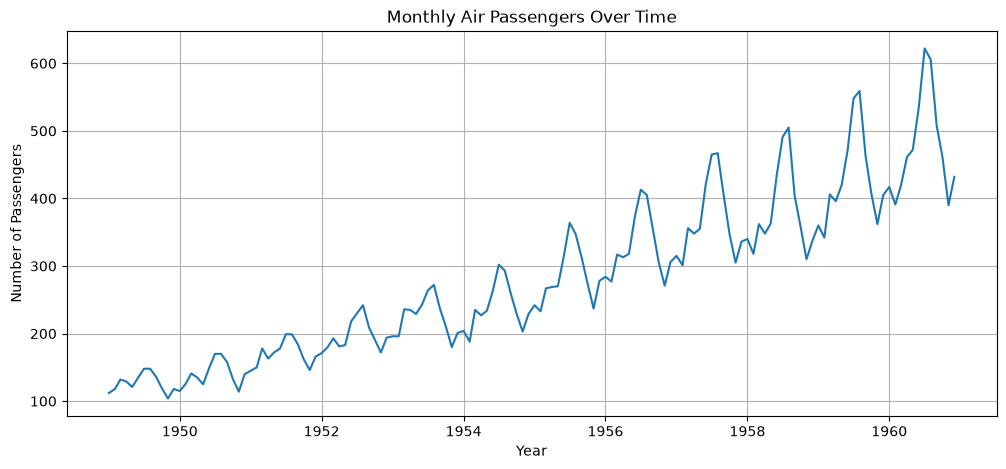

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(df["ds"], df["y"])

plt.title("Monthly Air Passengers Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")

plt.grid(True)
plt.show()

In [8]:
df["y"].describe()

count    144.000000
mean     280.298611
std      119.966317
min      104.000000
25%      180.000000
50%      265.500000
75%      360.500000
max      622.000000
Name: y, dtype: float64

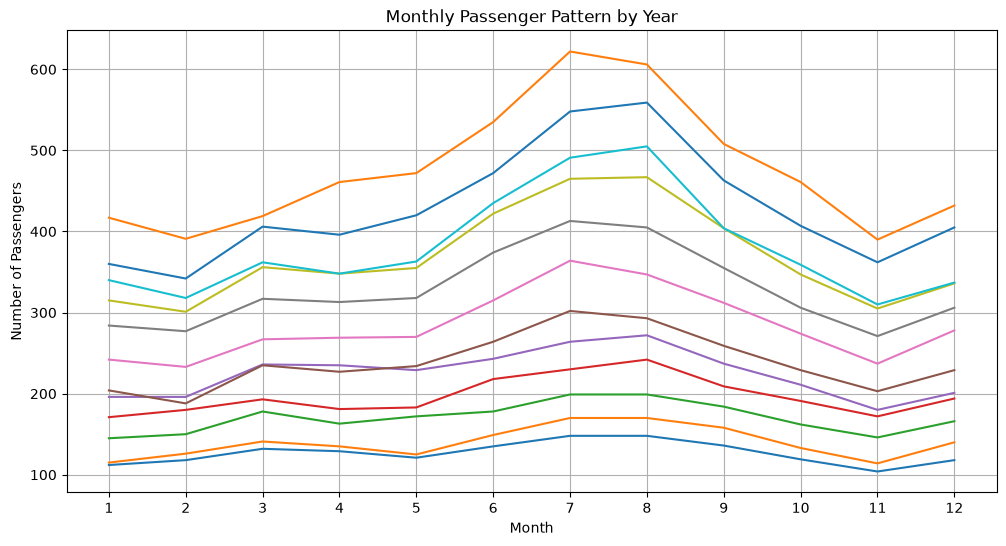

In [9]:
# Extract month and year
df["year"] = df["ds"].dt.year
df["month"] = df["ds"].dt.month

# Plot each year's monthly passenger pattern
plt.figure(figsize=(12, 6))

for year in df["year"].unique():
    yearly_data = df[df["year"] == year]
    plt.plot(yearly_data["month"], yearly_data["y"], label=str(year))

plt.title("Monthly Passenger Pattern by Year")
plt.xlabel("Month")
plt.ylabel("Number of Passengers")
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

In [10]:
monthly_average = df.groupby("month")["y"].mean()

print(monthly_average)

month
1     241.750000
2     235.000000
3     270.166667
4     267.083333
5     271.833333
6     311.666667
7     351.333333
8     351.083333
9     302.416667
10    266.583333
11    232.833333
12    261.833333
Name: y, dtype: float64


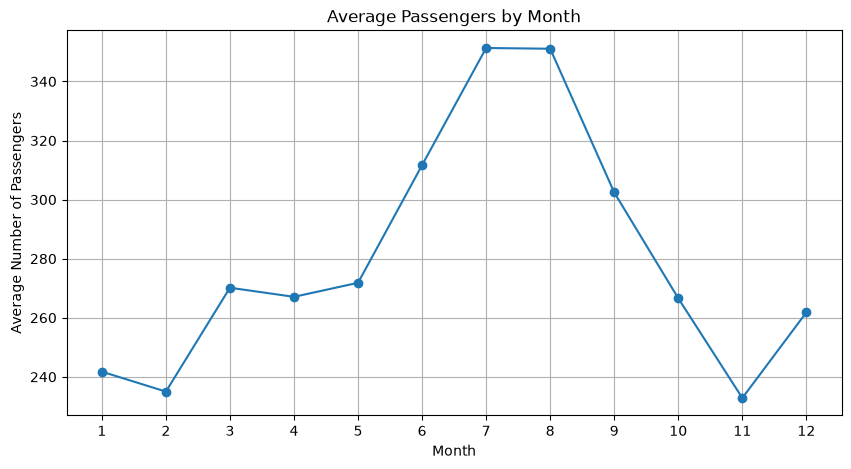

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(monthly_average.index, monthly_average.values, marker="o")

plt.title("Average Passengers by Month")
plt.xlabel("Month")
plt.ylabel("Average Number of Passengers")
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

In [12]:
# Keep only the columns required for forecasting
df = df[["ds", "y"]].copy()

print(df.head())
print(df.shape)

          ds    y
0 1949-01-01  112
1 1949-02-01  118
2 1949-03-01  132
3 1949-04-01  129
4 1949-05-01  121
(144, 2)


In [13]:
# Calculate the training size
train_size = int(len(df) * 0.80)

# Chronological train-test split
train = df.iloc[:train_size].copy()
test = df.iloc[train_size:].copy()

print("Total records:", len(df))
print("Training records:", len(train))
print("Testing records:", len(test))

print("\nTraining period:")
print(train["ds"].min(), "to", train["ds"].max())

print("\nTesting period:")
print(test["ds"].min(), "to", test["ds"].max())

Total records: 144
Training records: 115
Testing records: 29

Training period:
1949-01-01 00:00:00 to 1958-07-01 00:00:00

Testing period:
1958-08-01 00:00:00 to 1960-12-01 00:00:00


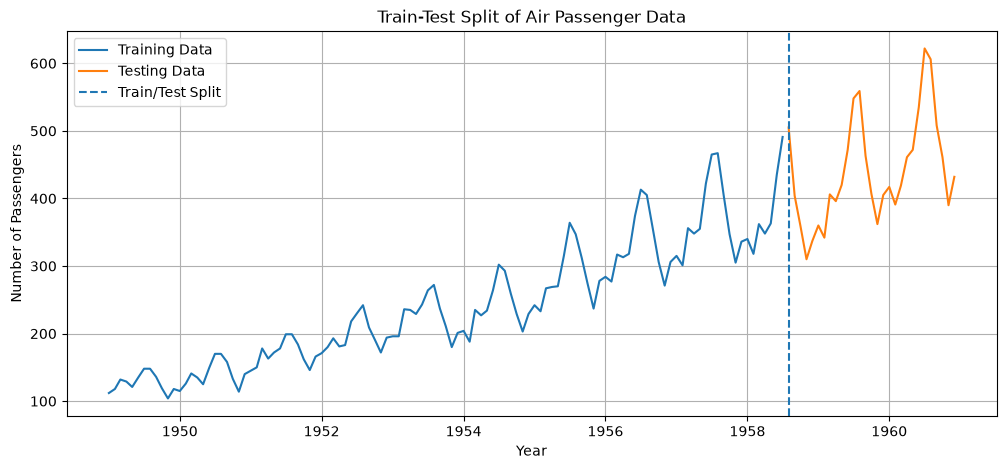

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(train["ds"], train["y"], label="Training Data")
plt.plot(test["ds"], test["y"], label="Testing Data")

plt.axvline(test["ds"].iloc[0], linestyle="--", label="Train/Test Split")

plt.title("Train-Test Split of Air Passenger Data")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
# Create Prophet model
model = Prophet()

# Train the model using training data
model.fit(train)

print("Prophet model trained successfully!")

16:06:04 - cmdstanpy - INFO - Chain [1] start processing
16:06:04 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully!


In [16]:
# Create dates corresponding to the test period
future_test = test[["ds"]].copy()

# Generate predictions
forecast_test = model.predict(future_test)

# Display the predictions
forecast_test[["ds", "yhat", "yhat_lower", "yhat_upper"]].head()

,ds,yhat,yhat_lower,yhat_upper
0,1958-08-01,448.082967,425.968601,469.929133
1,1958-09-01,418.234783,399.020935,440.380071
2,1958-10-01,387.593947,365.328978,408.648632
3,1958-11-01,361.402719,339.798987,384.456289
4,1958-12-01,388.283030,367.181955,409.141861


In [17]:
# Actual values from the test dataset
actual = test["y"].values

# Predicted values from Prophet
predicted = forecast_test["yhat"].values

# Calculate evaluation metrics
mae = mean_absolute_error(actual, predicted)
mse = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)

print("Model Evaluation Results")
print("------------------------")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")

Model Evaluation Results
------------------------
MAE  : 33.90
MSE  : 1708.55
RMSE : 41.33


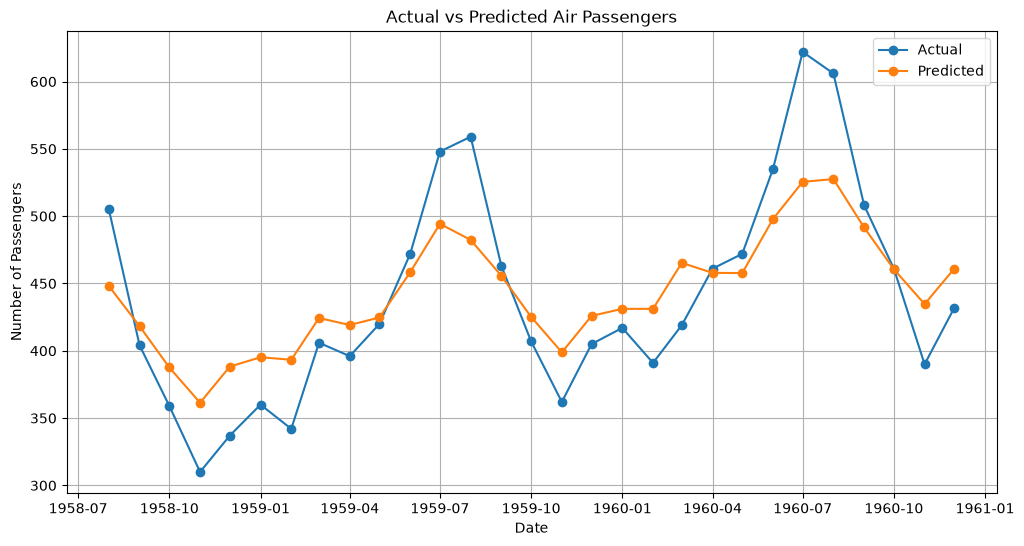

In [18]:
plt.figure(figsize=(12, 6))

# Actual test values
plt.plot(
    test["ds"],
    test["y"],
    label="Actual",
    marker="o"
)

# Predicted test values
plt.plot(
    forecast_test["ds"],
    forecast_test["yhat"],
    label="Predicted",
    marker="o"
)

plt.title("Actual vs Predicted Air Passengers")
plt.xlabel("Date")
plt.ylabel("Number of Passengers")

plt.legend()
plt.grid(True)

plt.show()

In [19]:
# Create the final Prophet model
final_model = Prophet()

# Train on the complete historical dataset
final_model.fit(df)

print("Final Prophet model trained on all 144 observations!")

16:06:04 - cmdstanpy - INFO - Chain [1] start processing
16:06:04 - cmdstanpy - INFO - Chain [1] done processing


Final Prophet model trained on all 144 observations!


In [20]:
# Create dates for the next 12 months
future = final_model.make_future_dataframe(periods=12, freq="MS")

print(future.tail(12))

            ds
144 1961-01-01
145 1961-02-01
146 1961-03-01
147 1961-04-01
148 1961-05-01
149 1961-06-01
150 1961-07-01
151 1961-08-01
152 1961-09-01
153 1961-10-01
154 1961-11-01
155 1961-12-01


In [21]:
# Generate the forecast
future_forecast = final_model.predict(future)

# Display only the next 12 months
future_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(12)

,ds,yhat,yhat_lower,yhat_upper
144,1961-01-01,466.196355,438.028201,495.358964
145,1961-02-01,460.660944,433.106899,489.276448
146,1961-03-01,493.071025,465.087783,522.751515
147,1961-04-01,491.706313,462.349444,521.321429
148,1961-05-01,496.003438,467.252088,524.707624
149,1961-06-01,537.105856,508.175773,564.039717
150,1961-07-01,576.677259,550.009234,603.927314
151,1961-08-01,577.100948,546.138612,604.250796
152,1961-09-01,528.534088,500.322486,557.544731
153,1961-10-01,493.379983,464.898099,520.578990


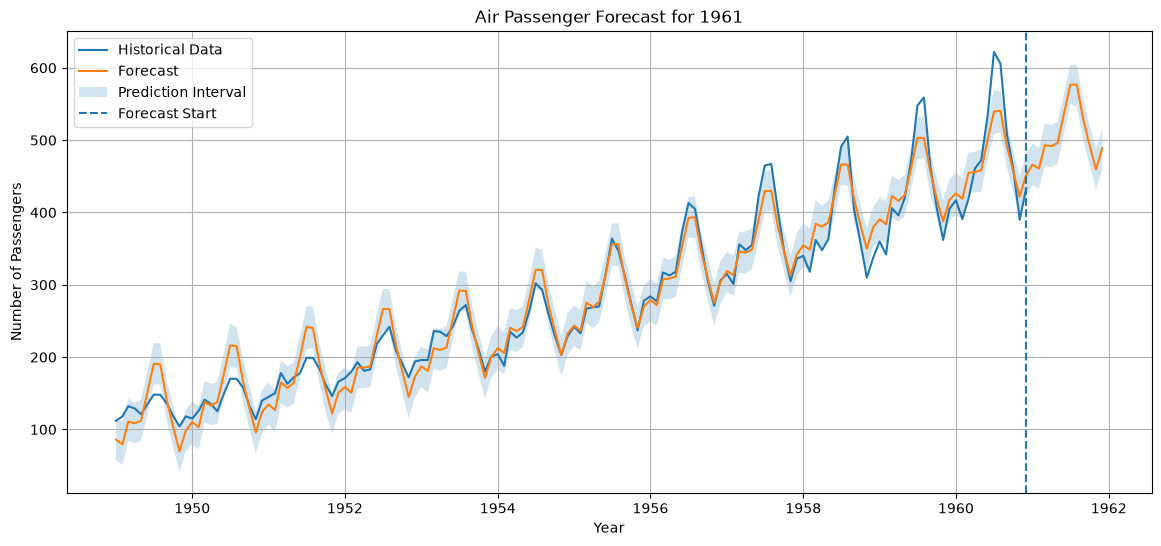

In [22]:
plt.figure(figsize=(14, 6))

# Historical data
plt.plot(
    df["ds"],
    df["y"],
    label="Historical Data"
)

# Future forecast
plt.plot(
    future_forecast["ds"],
    future_forecast["yhat"],
    label="Forecast"
)

# Forecast uncertainty interval
plt.fill_between(
    future_forecast["ds"],
    future_forecast["yhat_lower"],
    future_forecast["yhat_upper"],
    alpha=0.2,
    label="Prediction Interval"
)

# Mark where forecasting begins
plt.axvline(
    df["ds"].max(),
    linestyle="--",
    label="Forecast Start"
)

plt.title("Air Passenger Forecast for 1961")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")

plt.legend()
plt.grid(True)

plt.show()

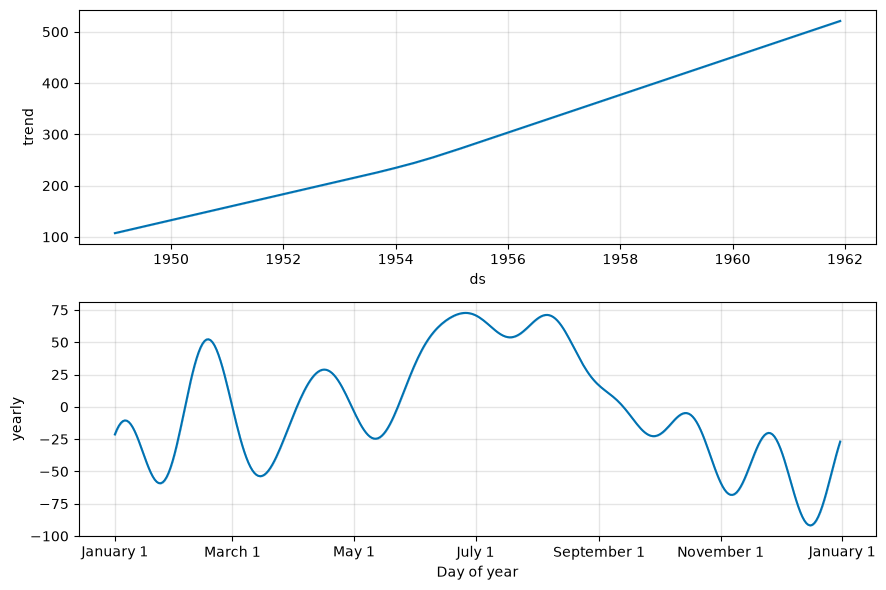

In [23]:
# Plot Prophet's trend and seasonality components
fig = final_model.plot_components(future_forecast)

plt.show()